<a href="https://colab.research.google.com/github/GamelinAl/mbtrack2_examples/blob/main/mbtrack2_IntrabeamScattering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intrabeam scattering

This notebook introduces the ``IntrabeamScattering`` class for **mbtrack2**.

The ``IntrabeamScattering`` class computes the IBS growth rate analytically each turn and applies corresponding kicks to each particle. Three models are available:
- **PM**: Modified Piwinski model
- **Bane**: Bane approximation for high-energy beams
- **CIMP**: Completely Integrated Modified Piwinski model


In [ ]:
pip install mbtrack2

# Tracking set-up

We begin by importing relevant libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mbtrack2 import Synchrotron, Electron
from mbtrack2.utilities import Optics
from mbtrack2.tracking import LongitudinalMap, SynchrotronRadiation, TransverseMap
from mbtrack2.tracking import IntrabeamScattering
from mbtrack2.tracking import Beam, Bunch, WakePotential
from mbtrack2.tracking import RFCavity, SynchrotronRadiation
from mbtrack2.tracking.monitors import BunchMonitor, WakePotentialMonitor


We define our lattice:
*   for this notebook we will use a ring with a lattice file to be able to illustrate the beta function and the scattering computations, however the code can still compute with average optic values if no lattice is loaded. For that we need to introduce a small dispersion at the local point.


In [ ]:
def soleil(mode = 'Uniform', load_lattice = True, IDs = "close"):
    """

    """

    h = 416
    particle = Electron()
    tau = np.array([6.56e-3, 6.56e-3, 3.27e-3])
    emit = np.array([3.9e-9, 3.9e-9*0.01])
    sigma_0 = 15e-12
    sigma_delta = 1.025e-3
    if load_lattice:
        lattice_file = "SOLEIL_OLD.mat"
        alpha = np.array([0, 0])

        optics = Optics(lattice_file=lattice_file, local_alpha=alpha, n_points=1e4)

        ring = Synchrotron(h, optics, particle, tau=tau, emit=emit,
                           sigma_0=sigma_0, sigma_delta=sigma_delta)

    else:
        L = 3.540969742590899e+02
        E0 = 2.75e9

        ac = 4.16e-4
        U0 = 1.171e6

        tune = np.array([18.15687, 10.22824, 0.00502])

        chro = [1.4,2.3]

        # mean values
        beta = np.array([3, 1.3])
        alpha = np.array([0, 0])
        dispersion = np.array([1e-3, 1e-3, 1e-3, 1e-3])
        optics = Optics(local_beta=beta, local_alpha=alpha,
        local_dispersion=dispersion)

        ring = Synchrotron(h, optics, particle, L=L, E0=E0, ac=ac, U0=U0, tau=tau,
        emit=emit, tune=tune, sigma_delta=sigma_delta,
        sigma_0=sigma_0, chro=chro)

    return ring


In [ ]:
ring = soleil()


This is not necessary but we can introduce a small 30% coupling.


In [ ]:
coupling = 30
ring.emit[1] = (coupling/100)*ring.emit[0]


We define and initialize the bunch.

In [ ]:
n_macroparticles = 10000
bunch_current = 1.2e-3

mybunch = Bunch(ring, mp_number=n_macroparticles, current=bunch_current, track_alive=True)
np.random.seed(42)
mybunch.init_gaussian()


We define and initialize the RF Cavity.

In [ ]:
V_rf  = 1.8e6
rf_single = RFCavity(ring, m=1, Vc=V_rf, theta=np.arccos(ring.U0 / V_rf))


We define the tracking elements that we are going to use.

In [ ]:
n_bin = 100
modelname = "CIMP"
long_map = LongitudinalMap(ring)
trans_map = TransverseMap(ring)
sr = SynchrotronRadiation(ring, switch=[1, 1, 1])
ibs = IntrabeamScattering(ring, model=modelname, n_points=200, n_bin=n_bin)


# Tracking

First we make a pass with the longitudinal and transverse map, as well as Synchrotron radiation and RF Cavity.


In [ ]:
long_map.track(mybunch)
trans_map.track(mybunch)
rf_single.track(mybunch)
sr.track(mybunch)


The IBS tracking method internally calls the following steps each turn:
1. `initialize(bunch)` — updates dynamic parameters (emittances, beam sizes, etc.)
2. `get_scattering_integrals(bunch)` — computes scattering integrals along the ring
3. `get_ibs_growthrate(bunch)` — computes growth rates from the integrals
4. `kick(bunch, r_x, r_y, r_p)` — applies momentum kicks to particles

These methods can also be called individually for diagnostics or step-by-step analysis.


We compute the IBS growth rates using `get_ibs_growthrate(bunch)`. This method internally calls `initialize()` and `get_scattering_integrals()`, so no separate setup step is required.


In [ ]:
r_x, r_y, r_p = ibs.get_ibs_growthrate(mybunch)
print(f"Mean growth rates: r_x={r_x.mean():.3f}, r_y={r_y.mean():.3f}, r_p={r_p.mean():.3f} [1/s]")


Mean growth rates: r_x=0.111, r_y=0.000, r_p=0.105 [1/s]


We can also access the underlying scattering integrals with `get_scattering_integrals(bunch)`. For all models it returns a unified set of three arrays: `vabq`, `v1aq`, `v1bq`.


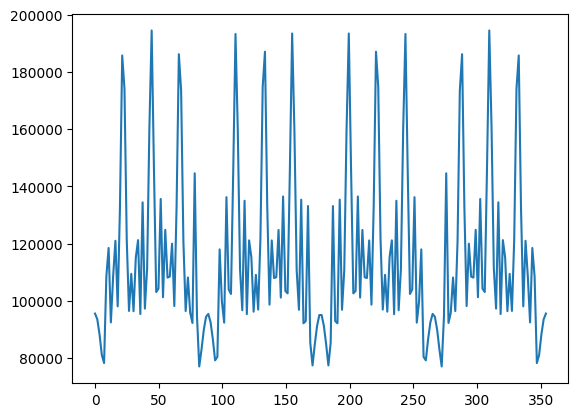

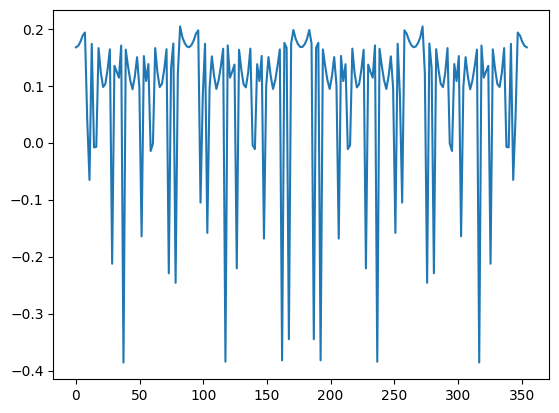

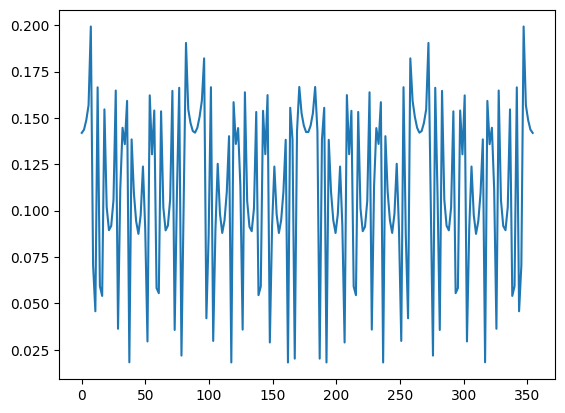

In [ ]:
vabq, v1aq, v1bq = ibs.get_scattering_integrals(mybunch)

s = np.linspace(0, ring.L, 200)  # longitudinal axis along the ring in [m]
for el in [vabq, v1aq, v1bq]:
    plt.plot(s, el)
    plt.show()


After computing the scattering integrals, `get_ibs_growthrate()` returns arrays of growth rates `r_x`, `r_y`, `r_p` at each location around the ring.


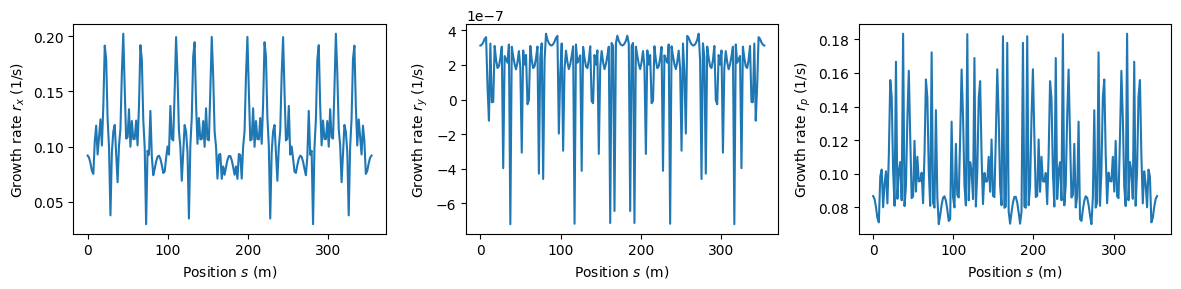

In [ ]:
s = np.linspace(0, ring.L, 200)
_, axs = plt.subplots(1, 3, figsize=(12, 3))
axs[0].plot(s, r_x)
axs[1].plot(s, r_y)
axs[2].plot(s, r_p)
for ax, label in zip(axs, ['$r_x$', '$r_y$', '$r_p$']):
    ax.set_xlabel('Position $s$ (m)')
    ax.set_ylabel(f'Growth rate {label} (1/s)')
plt.tight_layout()
plt.show()


The vertical growth rate is often small for flat-beam lattices. IBS growth rates are the emittance-increase contribution only; radiation damping (which counteracts it) is handled by the `SynchrotronRadiation` class.


To get the IBS growth *time* (in seconds) we take the inverse of the average growth rate.


In [ ]:
print(f"IBS growth times: T_x={1/r_x.mean():.3f} s, T_y={1/r_y.mean():.3f} s, T_p={1/r_p.mean():.3f} s")


IBS growth times: T_x=8.999 s, T_y=6381612.722 s, T_p=9.561 s


The `kick()` method applies the IBS kicks to the bunch, growing the emittance.


In [ ]:
ibs.kick(mybunch, r_x, r_y, r_p)


We can run a few kicks to check our emittance:

In [ ]:
print(mybunch.emit)


[3.89134138e-09 1.17761003e-09 1.54848020e-14]


In [ ]:
for i in range(100):
    ibs.track(mybunch)


In [ ]:
print(mybunch.emit)


[3.89160563e-09 1.17761016e-09 1.54854134e-14]


Since the beam parameters in the SOLEIL lattice lead to relatively weak IBS, we can demonstrate the emittance growth more clearly by applying artificially strong growth rates (IBS growth time on the order of milliseconds). Note that `kick()` expects numpy arrays for `r_x`, `r_y`, `r_p`.


In [ ]:
r_x_test = np.full(1, 1/5e-4)   # 0.5 ms IBS growth time
r_y_test = np.full(1, 1/15e-4)
r_p_test = np.full(1, 1/10e-4)
emit = []
for i in range(10000):
    ibs.kick(mybunch, r_x_test, r_y_test, r_p_test)
    emit.append(mybunch.emit)


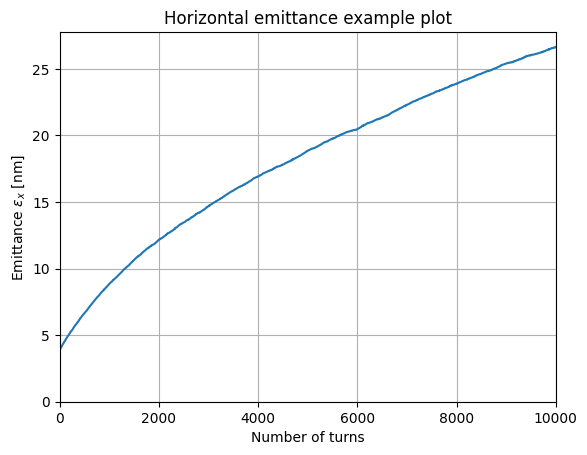

In [ ]:
emit = np.array(emit)
plt.plot(emit[:,0]*1e9)
plt.title("Horizontal emittance example plot")
plt.xlabel("Number of turns")
plt.ylabel("Emittance $\\epsilon_x$ [nm]")
plt.xlim(0, 10000)
plt.ylim(0,)
plt.grid()
plt.show()


# Using Piwinski Modified (PM)

Same procedure as before using the PM model.

In [ ]:
ring = soleil()
coupling = 30
ring.emit[1] = (coupling/100)*ring.emit[0]
n_macroparticles = 10000
bunch_current = 1.2e-3
mybunch = Bunch(ring, mp_number=n_macroparticles, current=bunch_current, track_alive=True)
np.random.seed(42)
mybunch.init_gaussian()
n_bin = 100
modelname = "PM"
long_map = LongitudinalMap(ring)
trans_map = TransverseMap(ring)
sr = SynchrotronRadiation(ring, switch=[1, 1, 1])
ibs = IntrabeamScattering(ring, model=modelname, n_points=200, n_bin=n_bin)
long_map.track(mybunch)
trans_map.track(mybunch)
rf_single.track(mybunch)
sr.track(mybunch)


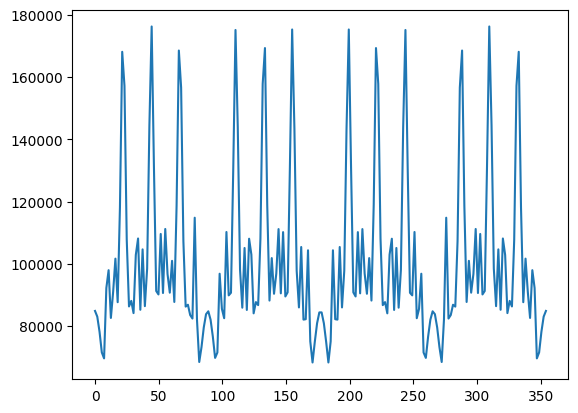

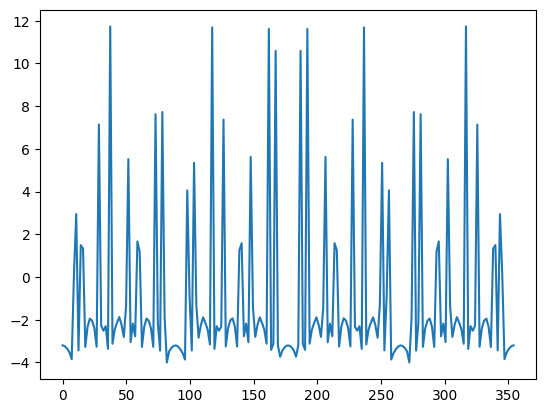

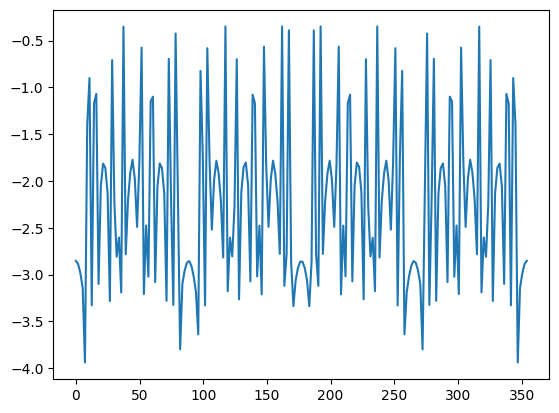

In [ ]:
vabq, v1aq, v1bq = ibs.get_scattering_integrals(mybunch)
for el in [vabq, v1aq, v1bq]:
    plt.plot(s, el)
    plt.show()


In [ ]:
r_x, r_y, r_p = ibs.get_ibs_growthrate(mybunch)
print(r_x.mean(), r_y.mean(), r_p.mean())


0.0976501512538186 -2.064997862347465e-06 0.09103635935124994


In [ ]:
print(mybunch.emit)


[3.89131382e-09 1.17761004e-09 1.54848655e-14]


In [ ]:
for i in range(100):
    r_x, r_y, r_p = ibs.get_ibs_growthrate(mybunch)
    ibs.kick(mybunch, r_x, r_y, r_p)


In [ ]:
print(mybunch.emit)


[3.89156213e-09 1.17761014e-09 1.54853115e-14]


In [ ]:
r_x_test = np.full(1, 1/5e-4)
r_y_test = np.full(1, 1/15e-4)
r_p_test = np.full(1, 1/10e-4)
emit = []
for i in range(10000):
    ibs.kick(mybunch, r_x_test, r_y_test, r_p_test)
    emit.append(mybunch.emit)


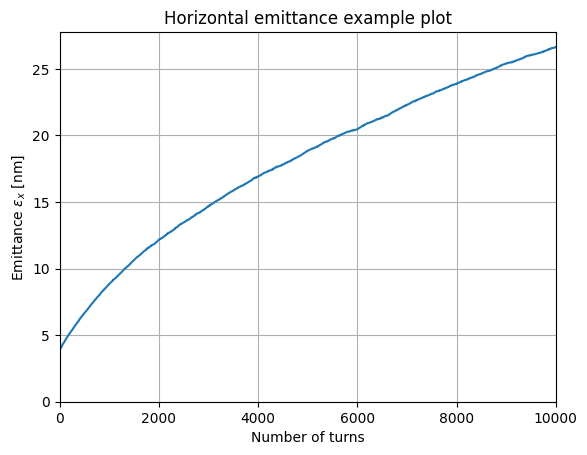

In [ ]:
emit = np.array(emit)
plt.plot(emit[:,0]*1e9)
plt.title("Horizontal emittance example plot")
plt.xlabel("Number of turns")
plt.ylabel("Emittance $\\epsilon_x$ [nm]")
plt.xlim(0, 10000)
plt.ylim(0,)
plt.grid()
plt.show()


# Using Bane Model

Same procedure as before using Bane.

In [ ]:
ring = soleil()
coupling = 30
ring.emit[1] = (coupling/100)*ring.emit[0]
n_macroparticles = 10000
bunch_current = 1.2e-3
mybunch = Bunch(ring, mp_number=n_macroparticles, current=bunch_current, track_alive=True)
np.random.seed(42)
mybunch.init_gaussian()
n_bin = 100
modelname = "Bane"
long_map = LongitudinalMap(ring)
trans_map = TransverseMap(ring)
sr = SynchrotronRadiation(ring, switch=[1, 1, 1])
ibs = IntrabeamScattering(ring, model=modelname, n_points=200, n_bin=n_bin)
long_map.track(mybunch)
trans_map.track(mybunch)
rf_single.track(mybunch)
sr.track(mybunch)


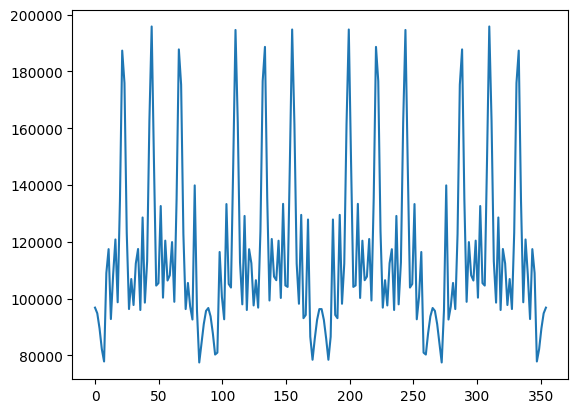

In [ ]:
vabq, v1aq, v1bq = ibs.get_scattering_integrals(mybunch)
plt.plot(s, vabq)
plt.show()


In [ ]:
r_x, r_y, r_p = ibs.get_ibs_growthrate(mybunch)
print(r_x.mean(), r_y.mean(), r_p.mean())


0.11147795509750155 0.0 0.10455523612738783


In [ ]:
print(mybunch.emit)


[3.89131382e-09 1.17761004e-09 1.54848655e-14]


In [ ]:
for i in range(100):
    # r_x, r_y, r_p = ibs.get_ibs_growthrate(mybunch)
    # ibs.kick(mybunch, r_x, r_y, r_p)
    ibs.track(mybunch)

In [ ]:
print(mybunch.emit)


[3.89158277e-09 1.17761018e-09 1.54853496e-14]


In [ ]:
r_x_test = np.full(1, 1/5e-4)
r_y_test = np.full(1, 1/15e-4)
r_p_test = np.full(1, 1/10e-4)
emit = []
for i in range(10000):
    ibs.kick(mybunch, r_x_test, r_y_test, r_p_test)
    emit.append(mybunch.emit)


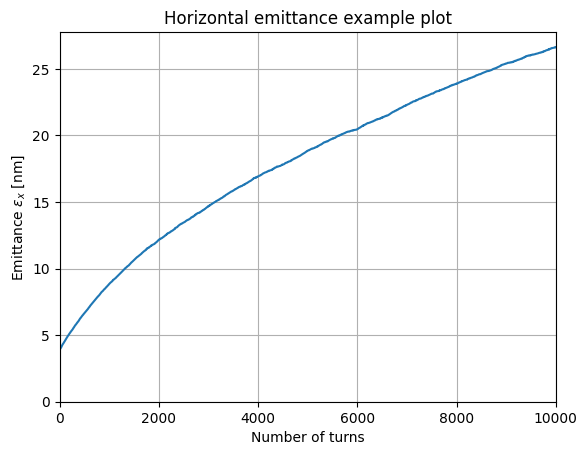

In [ ]:
emit = np.array(emit)
plt.plot(emit[:,0]*1e9)
plt.title("Horizontal emittance example plot")
plt.xlabel("Number of turns")
plt.ylabel("Emittance $\\epsilon_x$ [nm]")
plt.xlim(0, 10000)
plt.ylim(0,)
plt.grid()
plt.show()


# Using Completely Integrated Modified Piwinski (CIMP)

Same procedure as before using CIMP.

In [ ]:
ring = soleil()
coupling = 30
ring.emit[1] = (coupling/100)*ring.emit[0]
n_macroparticles = 10000
bunch_current = 1.2e-3
mybunch = Bunch(ring, mp_number=n_macroparticles, current=bunch_current, track_alive=True)
np.random.seed(42)
mybunch.init_gaussian()
n_bin = 100
modelname = "CIMP"
long_map = LongitudinalMap(ring)
trans_map = TransverseMap(ring)
sr = SynchrotronRadiation(ring, switch=[1, 1, 1])
ibs = IntrabeamScattering(ring, model=modelname, n_points=200, n_bin=n_bin)
long_map.track(mybunch)
trans_map.track(mybunch)
rf_single.track(mybunch)
sr.track(mybunch)


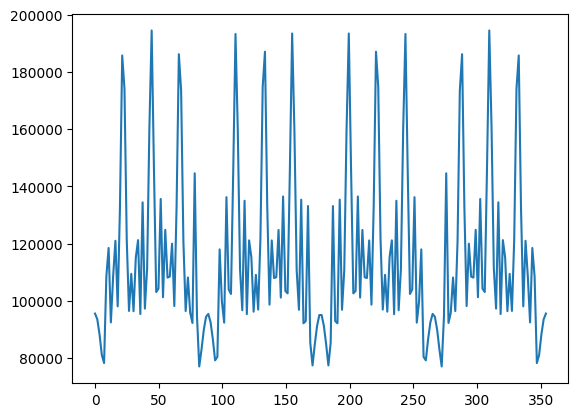

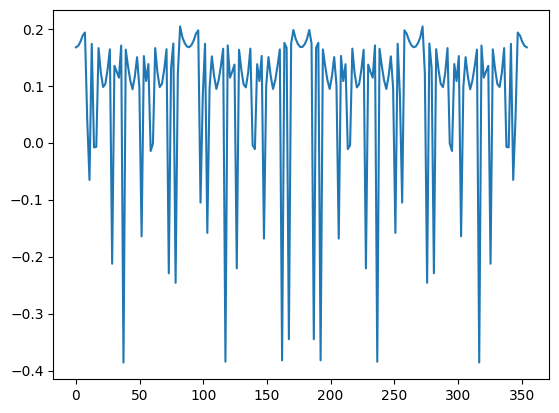

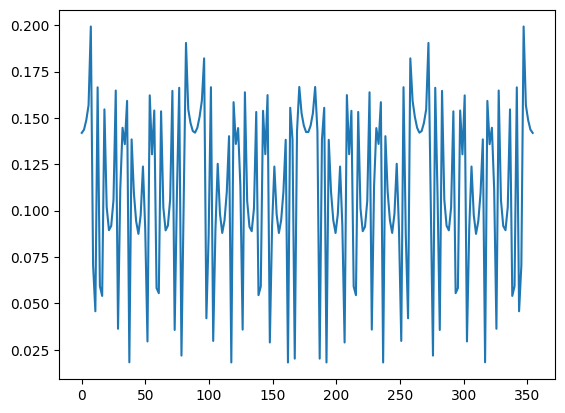

In [ ]:
vabq, v1aq, v1bq = ibs.get_scattering_integrals(mybunch)
for el in [vabq, v1aq, v1bq]:
    plt.plot(s, el)
    plt.show()


In [ ]:
r_x, r_y, r_p = ibs.get_ibs_growthrate(mybunch)
print(r_x.mean(), r_y.mean(), r_p.mean())


0.1111248248936668 1.567002015853262e-07 0.10459193436341944


In [ ]:
print(mybunch.emit)


[3.89131382e-09 1.17761004e-09 1.54848655e-14]


In [ ]:
for i in range(100):
    ibs.track(mybunch)


In [ ]:
print(mybunch.emit)


[3.89158253e-09 1.17761017e-09 1.54853497e-14]


In [ ]:
r_x_test = np.full(1, 1/5e-4)
r_y_test = np.full(1, 1/15e-4)
r_p_test = np.full(1, 1/10e-4)
emit = []
for i in range(10000):
    ibs.kick(mybunch, r_x_test, r_y_test, r_p_test)
    emit.append(mybunch.emit)


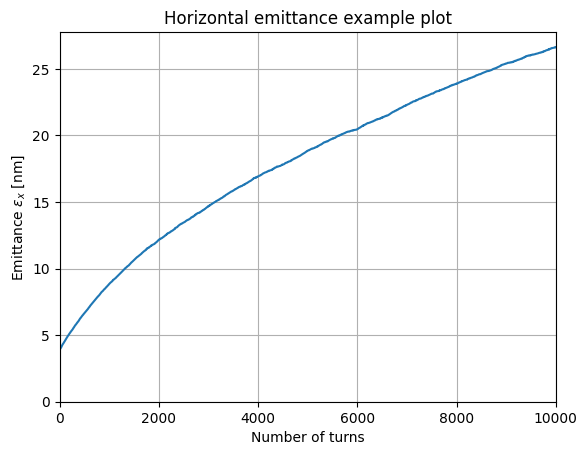

In [ ]:
emit = np.array(emit)
plt.plot(emit[:,0]*1e9)
plt.title("Horizontal emittance example plot")
plt.xlabel("Number of turns")
plt.ylabel("Emittance $\\epsilon_x$ [nm]")
plt.xlim(0, 10000)
plt.ylim(0,)
plt.grid()
plt.show()
